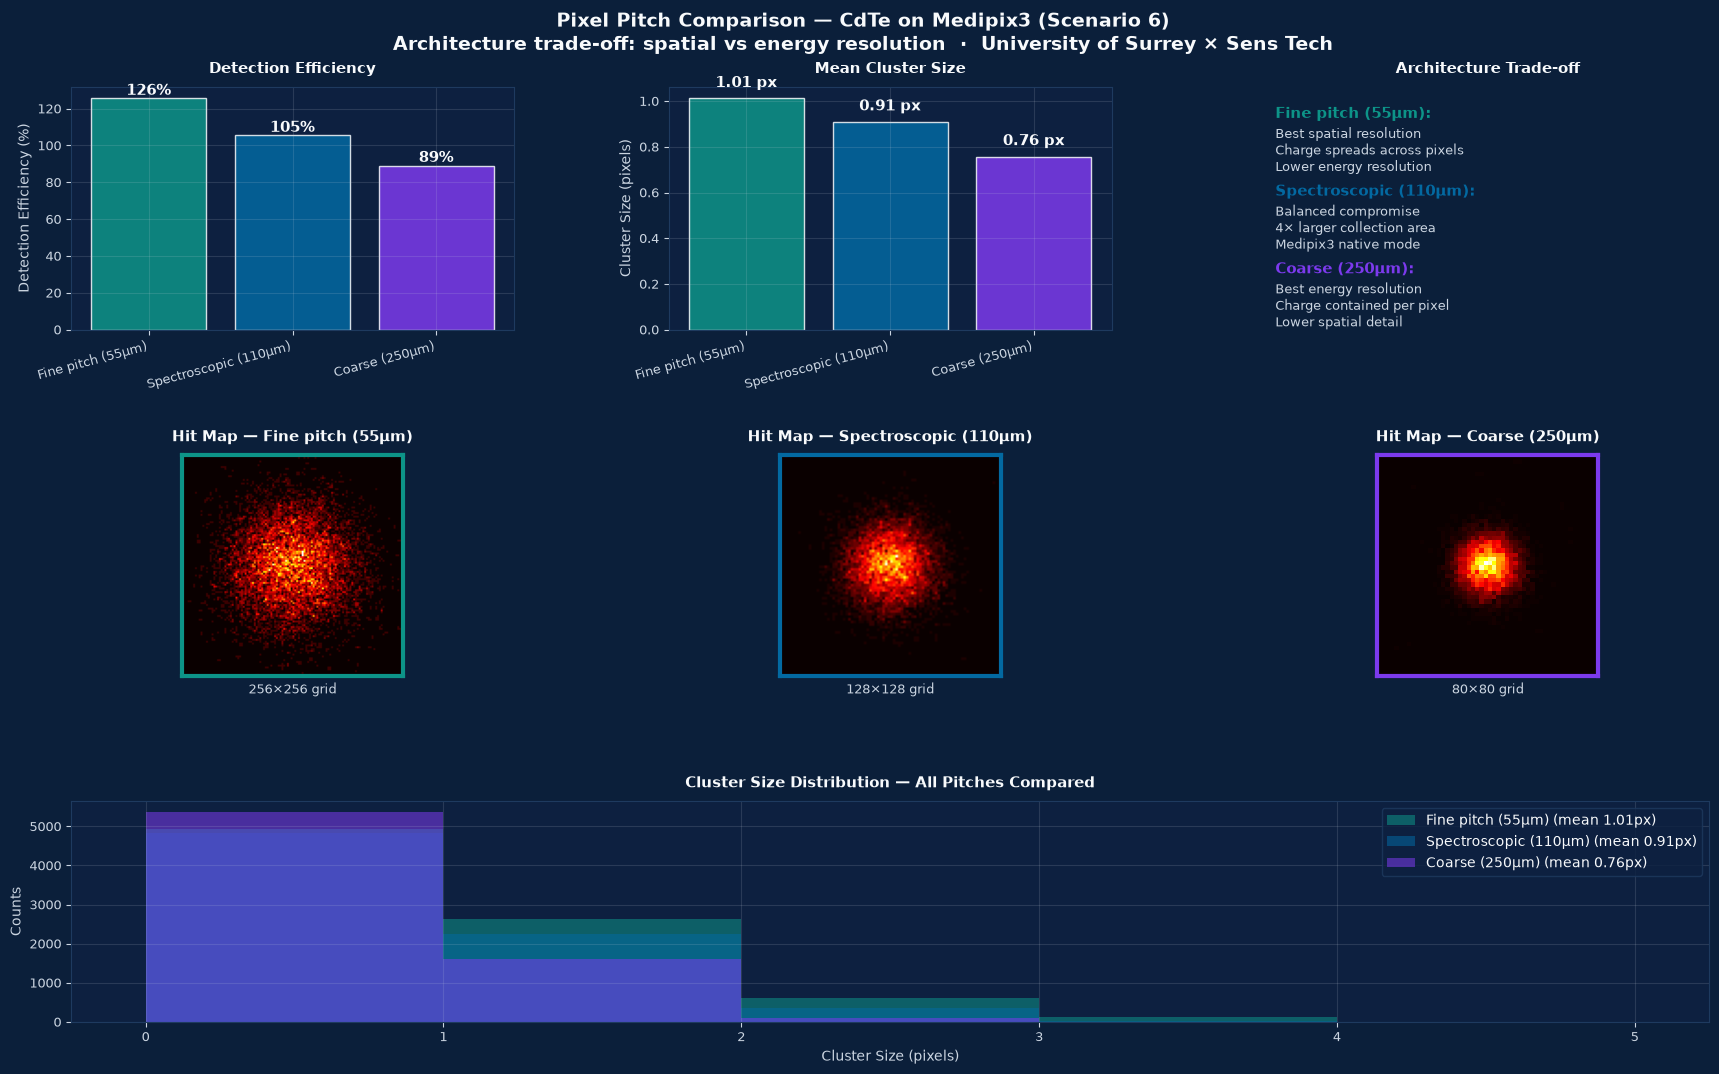

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/s6_pitch_dashboard.png

── Summary ───────────────────────────────────
  Fine pitch (55μm)         → 12,554 hits | 125.5% | cluster 1.01px
  Spectroscopic (110μm)     → 10,543 hits | 105.4% | cluster 0.91px
  Coarse (250μm)            →  8,909 hits |  89.1% | cluster 0.76px


In [1]:
"""
Scenario 6 — Pixel Pitch Comparison Dashboard
Fine vs spectroscopic vs coarse pitch — which architecture suits CdTe best?
"""

import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

modes = [
    ("fine",    "Fine pitch (55μm)",     55,  "256×256"),
    ("spectro", "Spectroscopic (110μm)", 110, "128×128"),
    ("coarse",  "Coarse (250μm)",        250, "80×80"),
]
n_events = 10000

results = []
hit_maps = []
charge_specs = []
cluster_dists = []

for mode_key, label, pitch, array in modes:
    path = os.path.join(BASE, f"s6_cdte_pitch{mode_key}.root")
    f = uproot.open(path)
    pc = f[f"DetectorHistogrammer/{DET}/charge/pixel_charge;1"].to_numpy()
    hm = f[f"DetectorHistogrammer/{DET}/hit_map;1"].to_numpy()
    cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()
    cc = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()

    hits = int(pc[0].sum())
    mean_q = np.average(pc[1][:-1], weights=pc[0] + 1e-9)
    mean_cs = np.average(cs[1][:-1], weights=cs[0] + 1e-9)
    mean_cc = np.average(cc[1][:-1], weights=cc[0] + 1e-9)

    results.append({
        "key": mode_key, "label": label, "pitch": pitch, "array": array,
        "hits": hits, "efficiency": (hits / n_events) * 100,
        "mean_pixel_charge": mean_q, "mean_cluster_charge": mean_cc,
        "mean_cluster_size": mean_cs,
    })
    hit_maps.append(hm[0])
    charge_specs.append(pc)
    cluster_dists.append(cs)

NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE, PURP = "#0D9488", "#0369A1", "#7C3AED"

def style_ax(ax, title):
    ax.set_facecolor("#0D2040")
    ax.tick_params(colors=LGRAY, labelsize=9)
    ax.xaxis.label.set_color(LGRAY); ax.yaxis.label.set_color(LGRAY)
    ax.title.set_color(WHITE)
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
    ax.grid(True, alpha=0.15, color=LGRAY)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor(NAVY)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.06, right=0.97, top=0.91, bottom=0.06,
                       height_ratios=[1.1, 1, 1])

colors = [TEAL, BLUE, PURP]

# Panel 1 — efficiency comparison
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "Detection Efficiency")
effs = [r["efficiency"] for r in results]
bars = ax1.bar([r["label"] for r in results], effs, color=colors,
               alpha=0.85, edgecolor=WHITE, linewidth=1)
for bar, r in zip(bars, results):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{r['efficiency']:.0f}%", ha="center", color=WHITE,
             fontsize=11, fontweight="bold")
ax1.set_ylabel("Detection Efficiency (%)")
plt.setp(ax1.get_xticklabels(), rotation=15, ha="right")

# Panel 2 — cluster size comparison
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Mean Cluster Size")
cs_vals = [r["mean_cluster_size"] for r in results]
bars = ax2.bar([r["label"] for r in results], cs_vals, color=colors,
               alpha=0.85, edgecolor=WHITE, linewidth=1)
for bar, r in zip(bars, results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{r['mean_cluster_size']:.2f} px", ha="center", color=WHITE,
             fontsize=11, fontweight="bold")
ax2.set_ylabel("Cluster Size (pixels)")
plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")

# Panel 3 — trade-off explanation
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0D2040")
ax3.axis("off")
style_ax(ax3, "Architecture Trade-off")
explanation = [
    ("Fine pitch (55μm):", TEAL,
     "Best spatial resolution\nCharge spreads across pixels\nLower energy resolution"),
    ("Spectroscopic (110μm):", BLUE,
     "Balanced compromise\n4× larger collection area\nMedipix3 native mode"),
    ("Coarse (250μm):", PURP,
     "Best energy resolution\nCharge contained per pixel\nLower spatial detail"),
]
for i, (title, color, body) in enumerate(explanation):
    y = 0.92 - i * 0.32
    ax3.text(0.02, y, title, color=color, fontsize=11, fontweight="bold",
             transform=ax3.transAxes, va="top")
    ax3.text(0.02, y - 0.08, body, color=LGRAY, fontsize=9,
             transform=ax3.transAxes, va="top")

# Hit maps row
for i, r in enumerate(results):
    ax = fig.add_subplot(gs[1, i])
    style_ax(ax, f"Hit Map — {r['label']}")
    hm = hit_maps[i]
    # Crop proportionally to the pixel grid
    c = hm.shape[0] // 2
    cr = min(60, hm.shape[0] // 3)
    ax.imshow(hm[c-cr:c+cr, c-cr:c+cr], cmap="hot", origin="lower",
              aspect="equal")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(colors[i]); s.set_linewidth(3)
    ax.text(0.5, -0.08, f"{r['array']} grid", transform=ax.transAxes,
            ha="center", color=LGRAY, fontsize=9)

# Cluster size distribution overlay
ax4 = fig.add_subplot(gs[2, :])
style_ax(ax4, "Cluster Size Distribution — All Pitches Compared")
for i, r in enumerate(results):
    cs = cluster_dists[i]
    mask = (cs[0] > 0) & (cs[1][:-1] < 15)
    ax4.bar(cs[1][:-1][mask], cs[0][mask], width=np.diff(cs[1])[mask],
            color=colors[i], alpha=0.55,
            label=f"{r['label']} (mean {r['mean_cluster_size']:.2f}px)")
ax4.set_xlabel("Cluster Size (pixels)")
ax4.set_ylabel("Counts")
ax4.legend(loc="upper right", fontsize=10, labelcolor=WHITE,
           facecolor="#0D2040", edgecolor="#1E3A5F")

fig.suptitle("Pixel Pitch Comparison — CdTe on Medipix3 (Scenario 6)\n"
             "Architecture trade-off: spatial vs energy resolution  ·  University of Surrey × Sens Tech",
             fontsize=14, fontweight="bold", color=WHITE, y=0.98)

out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/s6_pitch_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

print("\n── Summary ───────────────────────────────────")
for r in results:
    print(f"  {r['label']:<25} → {r['hits']:>6,} hits | {r['efficiency']:>5.1f}% | "
          f"cluster {r['mean_cluster_size']:.2f}px")